# 🎮 Experiment 6: K-Nearest Neighbors (KNN) on Video Game Sales

**Date:** 20/02/2026

## 🎯 Aim
To apply K-Nearest Neighbors algorithm on video game sales data and find the optimal k value.

## 📘 Theory
KNN is a supervised learning algorithm that classifies data based on the majority class among the k nearest neighbors.

It is simple, non-parametric, and works well for pattern recognition tasks.

## 📦 Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 📂 Load Dataset

In [3]:
# Ensure vgsales.csv is in the same directory

df = pd.read_csv("vgsales.csv")
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


## 🧹 Handling Missing Values

In [4]:
df = df.dropna()

## 🎯 Creating Sales Categories

In [5]:
q1 = df['Global_Sales'].quantile(0.33)
q2 = df['Global_Sales'].quantile(0.66)

def sales_cat(x):
    if x <= q1:
        return 0
    elif x <= q2:
        return 1
    else:
        return 2

df['Sales_Class'] = df['Global_Sales'].apply(sales_cat)

df[['Global_Sales','Sales_Class']].head()

,Global_Sales,Sales_Class
0,82.74,2
1,40.24,2
2,35.82,2
3,33.00,2
4,31.37,2


## 🔍 Feature Selection

In [6]:
X = df[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']]
y = df['Sales_Class']

## ⚖️ Feature Scaling

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## ✂️ Train-Test Split

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

## 🔍 Finding Optimal k Value

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

k_values = range(1, 21)
train_scores = []
test_scores = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    train_scores.append(knn_temp.score(X_train, y_train))
    test_scores.append(knn_temp.score(X_test, y_test))

## 📈 Accuracy vs k Plot

Optimal k value: 7


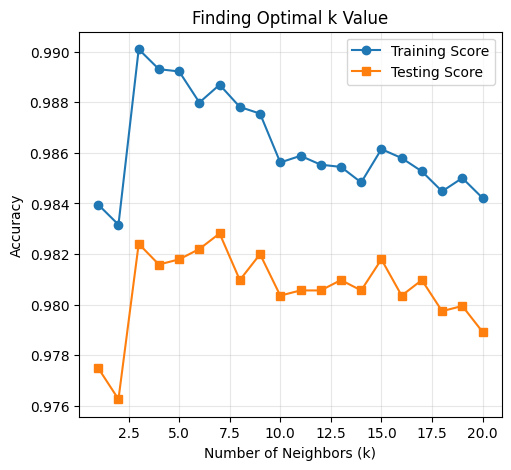

In [10]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(k_values, train_scores, 'o-', label='Training Score')
plt.plot(k_values, test_scores, 's-', label='Testing Score')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('Finding Optimal k Value')
plt.legend()
plt.grid(alpha=0.3)

optimal_k = k_values[np.argmax(test_scores)]
print(f"Optimal k value: {optimal_k}")

## 🧠 Training Final KNN Model

In [11]:
knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
y_pred_proba_knn = knn.predict_proba(X_test)

## 📊 Model Evaluation

In [12]:
print(f"\nModel Performance (k={optimal_k}):")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))

print("\nClassification Report:")
print(classification_report(
    y_test, y_pred_knn,
    target_names=['Low Sales','Medium Sales','High Sales']
))


Model Performance (k=7):
Accuracy: 0.9828150572831423

Classification Report:
              precision    recall  f1-score   support

   Low Sales       0.99      0.98      0.99      1691
Medium Sales       0.97      0.98      0.97      1554
  High Sales       0.99      0.99      0.99      1643

    accuracy                           0.98      4888
   macro avg       0.98      0.98      0.98      4888
weighted avg       0.98      0.98      0.98      4888



## 📏 Distance Metric Comparison

In [13]:
print("\n📊 Comparing Distance Metrics:")
distance_metrics = ['euclidean', 'manhattan', 'chebyshev']

for metric in distance_metrics:
    knn_metric = KNeighborsClassifier(
        n_neighbors=optimal_k,
        metric=metric
    )
    knn_metric.fit(X_train, y_train)
    score = knn_metric.score(X_test, y_test)
    print(f"{metric.capitalize()}: {score:.4f}")


📊 Comparing Distance Metrics:
Euclidean: 0.9828
Manhattan: 0.9822
Chebyshev: 0.9828


## 🧭 PCA Decision Boundary Visualization

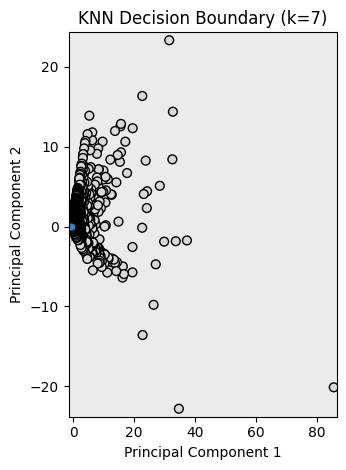

In [14]:
from sklearn.decomposition import PCA

plt.subplot(1,2,2)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

h = 0.02
x_min, x_max = X_pca[:,0].min()-1, X_pca[:,0].max()+1
y_min, y_max = X_pca[:,1].min()-1, X_pca[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

knn_2d = KNeighborsClassifier(n_neighbors=optimal_k)
knn_2d.fit(X_pca, y)

Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='tab20c')
plt.scatter(X_pca[:,0], X_pca[:,1], c=y,
            cmap='tab20c', edgecolors='k', s=40)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'KNN Decision Boundary (k={optimal_k})')

plt.tight_layout()
plt.show()

## 🏁 Conclusion
KNN successfully classified video games into sales categories and optimal k improved model performance.